**รายละเอียดโจทย์การบ้าน: Hybrid Multi-Agent System**

ในโจทย์นี้ นักศึกษาจะได้ออกแบบและทดลองสร้างระบบ Multi-Agent ที่ผสมผสานความสามารถจากหลาย ๆ ตัวแทน ดังนี้

1. **ReAct (Research) Agent**

   * ใช้ฟังก์ชัน `search_wikipedia(term)` เพื่อดึงข้อมูลจาก Wikipedia ตามคำค้น

2. **Coding Agent**

   * ใช้ฟังก์ชัน `run_python_code(code)` เพื่อรันโค้ด Python จริง และส่งผลลัพธ์กลับมา
   * หลังรันแล้ว ให้สะท้อนผลลัพธ์ (self-reflection) เพื่อปรับปรุงโค้ดหรือคำอธิบายให้สมบูรณ์ยิ่งขึ้น
3. **Mixture-of-Agents Orchestrator**

   * ใช้ฟังก์ชัน `mixture_of_agents(user_prompt, agent_roles)`
   * กำหนดบทบาท (roles) ของ Proposer Agents อย่างน้อย 2 บทบาท (เช่น “Data Scientist”, “frontend developer”, “backend engineer”, “UX designer” เป็นต้น)
   * รวบรวม (aggregate) คำตอบจากแต่ละ Proposer แล้วสังเคราะห์ผลลัพธ์ออกมาเป็นคำตอบเดียว

> **สิ่งที่ต้องส่ง**
> * โค้ด Python ที่ประกอบด้วยการเรียกใช้ทั้ง `research_agent()`, `coding_agent()`, และ `mixture_of_agents()`


---

#### ตัวอย่างคำถามจำนวน 5 ข้อ (ในรูปแบบ Python list) สำหรับทดสอบระบบ

```python
questions = [
    # 1. หัวข้อ AI เบื้องต้น:
    "สรุปแนวคิดหลักของ 'Reinforcement Learning' จาก Wikipedia แล้วสร้างกราฟแสดง reward function ด้วย Python พร้อมสะท้อนผลลัพธ์ทุกขั้นตอน",

    # 2. วิเคราะห์ข้อมูลจริง:
    "ใช้ Research Agent ดึงข้อมูลสถิติ COVID-19 รายวันจาก Wikipedia จากนั้น Coding Agent คำนวณค่า moving average ของยอดผู้ติดเชื้อ 7 วัน และ Mixture-of-Agents ให้บทบาท 'Epidemiologist' และ 'Data Analyst' เสนอแนวทางจัดการข้อมูล",

    # 3. เปรียบเทียบอัลกอริทึม:
    "เปรียบเทียบเวลาในการรันอัลกอริทึม 'Quick Sort' และ 'Merge Sort' ด้วย Coding Agent พร้อม Self-Reflection ว่าการเลือกใช้โครงสร้างข้อมูลใดเหมาะสมกว่า และให้ Mixture-of-Agents สะท้อนมุมมองของ 'Algorithm Theorist' กับ 'Benchmark Specialist'",

    # 4. ออกแบบ Chatbot ง่าย ๆ:
    "สร้างระบบ Chatbot เบื้องต้น: Research Agent ค้นหา FAQ จาก Wikipedia, Coding Agent เขียนโค้ด Flask ให้สามารถรับข้อความและตอบกลับ, Mixture-of-Agents ให้บทบาท 'UX Designer' และ 'Backend Engineer' วิเคราะห์การทำงาน และสะท้อนปรับปรุง UX/UI",

    # 5. วิเคราะห์ชุดข้อมูล Titanic:
    "Research Agent สรุปที่มาของชุดข้อมูล Titanic จาก Wikipedia, Coding Agent โหลดข้อมูลและคำนวณอัตราการรอดชีวิตตามเพศและชั้นผู้โดยสาร พร้อม self-reflection, Mixture-of-Agents ให้บทบาท 'Statistician' และ 'Data Engineer' สรุปผลเชิงตีความ"
]
```

> แต่ละโจทย์จะต้องรันผ่านฟังก์ชัน
>
> ```python
> result = multi_agent_system(question)
> ```
>
> และ
>
> ```python
> final = mixture_of_agents(question, ["Role1", "Role2"])
> ```
>
> พร้อมแสดง output ทุกขั้นตอนและข้อคิดเห็น (reflection) ของแต่ละ agent ให้ครบถ้วน เพื่อให้เห็นภาพการทำงานร่วมกันของระบบ Multi-Agent Hybrid นี้อย่างชัดเจน


In [ ]:
!pip install python-dotenv openai requests wikipedia matplotlib pandas numpy

In [5]:
import os, io, json, textwrap, time, traceback, sys, ast, contextlib
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple

import IPython
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from openai import OpenAI

def clean_notebook():
    IPython.display.clear_output(wait=True)
    print("Notebook cleaned.")

!pip install python-dotenv openai requests wikipedia matplotlib pandas numpy

clean_notebook()
# Load environment variables
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
model_name =  "gpt-4o"   


Notebook cleaned.


In [6]:

def search_wikipedia(term: str, lang: str = "en", max_chars: int = 4000) -> Dict[str, Any]:
    """Fetch summary and page content from Wikipedia.
    Returns a dict: { 'term': str, 'summary': str, 'content': str, 'url': str }
    """
    try:
        # 1) Search for the page
        search_url = f"https://{lang}.wikipedia.org/w/api.php"
        params = {
            "action": "query",
            "list": "search",
            "srsearch": term,
            "format": "json"
        }
        r = requests.get(search_url, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()
        hits = data.get("query", {}).get("search", [])
        if not hits:
            return {"term": term, "summary": "", "content": "", "url": ""}
        page_title = hits[0]["title"]

        # 2) Get page content
        content_params = {
            "action": "query",
            "prop": "extracts",
            "explaintext": True,
            "titles": page_title,
            "format": "json",
            "redirects": 1
        }
        r2 = requests.get(search_url, params=content_params, timeout=20)
        r2.raise_for_status()
        d2 = r2.json()
        pages = d2.get("query", {}).get("pages", {})
        page = next(iter(pages.values()))
        extract = page.get("extract", "") or ""

        # 3) Summary endpoint (optional, for concise intro)
        summary_url = f"https://{lang}.wikipedia.org/api/rest_v1/page/summary/{page_title.replace(' ', '_')}"
        rs = requests.get(summary_url, timeout=20)
        summary = ""
        url = ""
        if rs.status_code == 200:
            ds = rs.json()
            summary = ds.get("extract", "") or ""
            url = ds.get("content_urls", {}).get("desktop", {}).get("page", "")

        # 4) Truncate to avoid over-long context
        if len(extract) > max_chars:
            extract = extract[:max_chars] + "...\n[truncated]"

        return {"term": term, "summary": summary, "content": extract, "url": url}
    except Exception as e:
        return {"term": term, "summary": "", "content": f"[search_wikipedia error: {e}]", "url": ""}


In [7]:

def run_python_code(code: str) -> Dict[str, Any]:
    """Execute Python code safely and capture stdout/stderr.
    Returns {'ok': bool, 'stdout': str, 'stderr': str, 'error': str|None}
    """
    # Minimal sandbox (note: running arbitrary code can be unsafe; use carefully)
    local_env: Dict[str, Any] = {}
    stdout_buffer, stderr_buffer = io.StringIO(), io.StringIO()

    try:
        compiled = compile(code, filename="<generated>", mode="exec")
        with contextlib.redirect_stdout(stdout_buffer):
            with contextlib.redirect_stderr(stderr_buffer):
                exec(compiled, {"__builtins__": __builtins__, "np": np, "pd": pd, "plt": plt}, local_env)
        return {
            "ok": True,
            "stdout": stdout_buffer.getvalue(),
            "stderr": stderr_buffer.getvalue(),
            "error": None
        }
    except Exception as e:
        return {
            "ok": False,
            "stdout": stdout_buffer.getvalue(),
            "stderr": stderr_buffer.getvalue(),
            "error": traceback.format_exc()
        }


In [8]:

def llm_chat(messages: List[Dict[str, str]], temperature: float = 0.2, max_tokens: int = 1200) -> str:
    """Call OpenAI Chat Completions with model gpt-4o and return the message content."""
    resp = client.chat.completions.create(
        model=model_name,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens
    )
    return resp.choices[0].message.content or ""

def llm_json(messages: List[Dict[str, str]], schema_hint: str, temperature: float = 0.0, max_tokens: int = 1200) -> Any:
    """Ask model to return JSON (with a simple system hint)."""
    sys_hint = {
        "role": "system",
        "content": f"Return **only** valid JSON matching this structure: {schema_hint}"
    }
    content = llm_chat([sys_hint] + messages, temperature=temperature, max_tokens=max_tokens)
    try:
        return json.loads(content)
    except json.JSONDecodeError:
        # last resort: try to extract JSON from text
        start = content.find("{")
        end = content.rfind("}")
        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(content[start:end+1])
            except Exception:
                pass
        return {"_raw": content, "_error": "Failed to parse JSON"}


In [9]:

def research_agent(user_question: str, lang: str = "en") -> Dict[str, Any]:
    # 1) Extract 1-3 search terms
    terms = llm_json(
        [
            {"role": "user", "content": f"Extract 1-3 concise Wikipedia search terms for: {user_question}"}
        ],
        schema_hint='{"terms": ["string", "..."]}'
    )
    term_list = terms.get("terms", [])
    if not term_list:
        term_list = [user_question]

    # 2) Query Wikipedia for each term
    results = [search_wikipedia(t, lang=lang) for t in term_list]

    # 3) Summarize with citations (URLs)
    summary_input = "\n\n".join(
        [f"TERM: {r['term']}\nURL: {r.get('url','')}\nSUMMARY: {r.get('summary','')[:800]}\nCONTENT: {r.get('content','')[:800]}" for r in results]
    )
    synth = llm_chat(
        [
            {"role": "system", "content": "You are a careful research assistant. Concisely summarize key points and provide citations as URLs."},
            {"role": "user", "content": f"Question: {user_question}\n\nSources:\n{summary_input}"}
        ],
        temperature=0.2, max_tokens=700
    )
    return {"question": user_question, "terms": term_list, "raw_sources": results, "summary": synth}


In [10]:

@dataclass
class CodeRun:
    code: str
    run: Dict[str, Any]
    reflection: str = ""
    repaired_code: str = ""
    repaired_run: Dict[str, Any] = None

def coding_agent(task_description: str, max_iterations: int = 2) -> CodeRun:
    # 1) Ask for Python code (single file, runnable in notebook)
    code = llm_chat(
        [
            {"role": "system", "content": "Write concise, runnable Python code for a Jupyter notebook. Use matplotlib for charts (no seaborn). Do not set custom colors/styles."},
            {"role": "user", "content": f"Task: {task_description}"}
        ],
        temperature=0.2, max_tokens=1400
    )

    # Extract fenced code if present
    def extract_code(text: str) -> str:
        if "```" in text:
            blocks = text.split("```")
            # find python block
            for i in range(1, len(blocks), 2):
                header = blocks[i].strip().split("\n", 1)[0].lower()
                body = blocks[i].split("\n", 1)[1] if "\n" in blocks[i] else ""
                if "python" in header or header == "":
                    return body
        return text

    code_snippet = extract_code(code)
    first_run = run_python_code(code_snippet)

    # 2) Self‑reflection
    reflection = llm_chat(
        [
            {"role": "system", "content": "You are a senior Python reviewer. Diagnose problems based on stdout/stderr and propose minimal fixes."},
            {"role": "user", "content": f"Task: {task_description}\n\nCODE:\n{code_snippet}\n\nSTDOUT:\n{first_run['stdout']}\n\nSTDERR/ERROR:\n{first_run['stderr']}\n{first_run['error'] or ''}\n\nGive a short reflection and a fixed code if needed."}
        ],
        temperature=0.2, max_tokens=900
    )

    repaired_code = ""
    repaired_run = None

    # Try to pull a repaired code block, if any
    extracted = reflection
    if "```" in extracted:
        blocks = extracted.split("```")
        for i in range(1, len(blocks), 2):
            header = blocks[i].strip().split("\n", 1)[0].lower()
            body = blocks[i].split("\n", 1)[1] if "\n" in blocks[i] else ""
            if "python" in header or header == "":
                repaired_code = body
                break

    if repaired_code and repaired_code.strip() != code_snippet.strip():
        repaired_run = run_python_code(repaired_code)

    return CodeRun(
        code=code_snippet,
        run=first_run,
        reflection=reflection,
        repaired_code=repaired_code,
        repaired_run=repaired_run
    )


In [11]:

def mixture_of_agents(user_prompt: str, agent_roles: List[str]) -> Dict[str, Any]:
    proposals = []
    for role in agent_roles:
        proposal = llm_chat(
            [
                {"role": "system", "content": f"You are acting as a {role}. Provide a clear, structured proposal addressing the user's prompt."},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.4, max_tokens=900
        )
        proposals.append({"role": role, "content": proposal})

    # Aggregate / Synthesize
    aggregate = llm_chat(
        [
            {"role": "system", "content": "Synthesize multiple expert proposals into a single, coherent plan with bullet points and clear rationale."},
            {"role": "user", "content": json.dumps(proposals, ensure_ascii=False)}
        ],
        temperature=0.2, max_tokens=900
    )
    return {"roles": agent_roles, "proposals": proposals, "final": aggregate}


In [12]:

def multi_agent_system(question: str, roles: List[str] = None, lang: str = "th") -> Dict[str, Any]:
    if roles is None:
        # ให้โมเดลเลือกบทบาท 2 ตัวอัตโนมัติ
        j = llm_json(
            [{"role": "user", "content": f"Pick 2 concise expert roles that best address this prompt: {question}"}],
            schema_hint='{"roles": ["string", "string"]}'
        )
        roles = j.get("roles", ["Data Scientist", "Backend Engineer"])

    research = research_agent(question, lang=lang)

    # อธิบายให้ Coding Agent ทำงานตามโจทย์ (Code-first)
    coding_task = f"""
    Based on this user question, write Python code to (if applicable) fetch/process data and produce the requested charts/tables.
    Use only matplotlib (no seaborn). Do not set custom colors or styles.
    If internet data is needed (e.g., Wikipedia or CSV), include requests/processing code and handle errors gracefully.
    Question: {question}
    """
    code_result = coding_agent(coding_task, max_iterations=2)

    mix = mixture_of_agents(question, roles)
    return {"research": research, "code": code_result, "mixture": mix, "roles": roles}


In [ ]:

questions = [
    # 1. หัวข้อ AI เบื้องต้น:
    "สรุปแนวคิดหลักของ 'Reinforcement Learning' จาก Wikipedia แล้วสร้างกราฟแสดง reward function ด้วย Python พร้อมสะท้อนผลลัพธ์ทุกขั้นตอน",

    # 2. วิเคราะห์ข้อมูลจริง:
    "ใช้ Research Agent ดึงข้อมูลสถิติ COVID-19 รายวันจาก Wikipedia จากนั้น Coding Agent คำนวณค่า moving average ของยอดผู้ติดเชื้อ 7 วัน และ Mixture-of-Agents ให้บทบาท 'Epidemiologist' และ 'Data Analyst' เสนอแนวทางจัดการข้อมูล",

    # 3. เปรียบเทียบอัลกอริทึม:
    "เปรียบเทียบเวลาในการรันอัลกอริทึม 'Quick Sort' และ 'Merge Sort' ด้วย Coding Agent พร้อม Self-Reflection ว่าการเลือกใช้โครงสร้างข้อมูลใดเหมาะสมกว่า และให้ Mixture-of-Agents สะท้อนมุมมองของ 'Algorithm Theorist' กับ 'Benchmark Specialist'",

    # 4. ออกแบบ Chatbot ง่าย ๆ:
    "สร้างระบบ Chatbot เบื้องต้น: Research Agent ค้นหา FAQ จาก Wikipedia, Coding Agent เขียนโค้ด Flask ให้สามารถรับข้อความและตอบกลับ, Mixture-of-Agents ให้บทบาท 'UX Designer' และ 'Backend Engineer' วิเคราะห์การทำงาน และสะท้อนปรับปรุง UX/UI",

    # 5. วิเคราะห์ชุดข้อมูล Titanic:
    "Research Agent สรุปที่มาของชุดข้อมูล Titanic จาก Wikipedia, Coding Agent โหลดข้อมูลและคำนวณอัตราการรอดชีวิตตามเพศและชั้นผู้โดยสาร พร้อม self-reflection, Mixture-of-Agents ให้บทบาท 'Statistician' และ 'Data Engineer' สรุปผลเชิงตีความ"
]
questions


["สรุปแนวคิดหลักของ 'Reinforcement Learning' จาก Wikipedia แล้วสร้างกราฟแสดง reward function ด้วย Python พร้อมสะท้อนผลลัพธ์ทุกขั้นตอน"]

In [14]:

def show_research(res):
    print("=== Research Summary ===")
    print(res["research"]["summary"][:2000])
    print("\nSources:")
    for s in res["research"]["raw_sources"]:
        if s.get("url"):
            print("-", s["url"])

def show_code(res):
    c = res["code"]
    print("=== Generated Code ===\n")
    print(c.code)
    print("\n--- First Run ---")
    print("OK:", c.run["ok"])
    print("STDOUT:\n", c.run["stdout"][:2000])
    if c.run["error"]:
        print("\nERROR:\n", c.run["error"][:2000])

    print("\n--- Reflection ---\n", c.reflection[:2000])

    if c.repaired_code:
        print("\n=== Repaired Code ===\n")
        print(c.repaired_code)
        if c.repaired_run:
            print("\n--- Repaired Run ---")
            print("OK:", c.repaired_run["ok"])
            print("STDOUT:\n", c.repaired_run["stdout"][:2000])
            if c.repaired_run["error"]:
                print("\nERROR:\n", c.repaired_run["error"][:2000])

def show_mixture(res):
    print("=== Roles ===", res["roles"])
    print("\n=== Final Synthesis ===\n")
    print(res["mixture"]["final"][:3000])


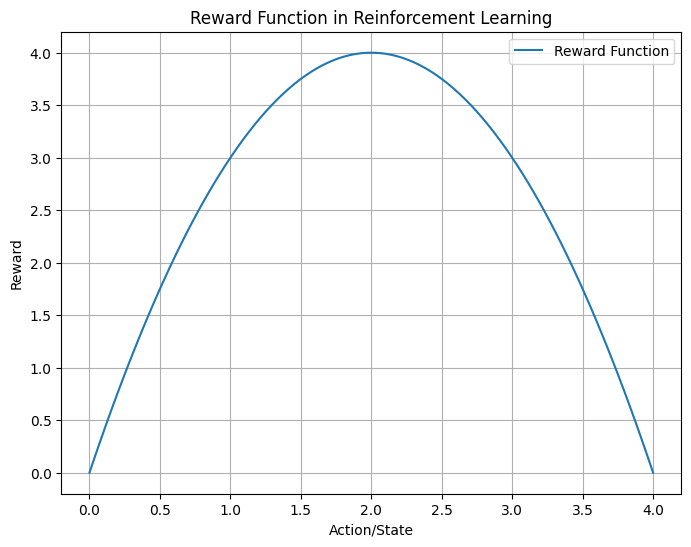

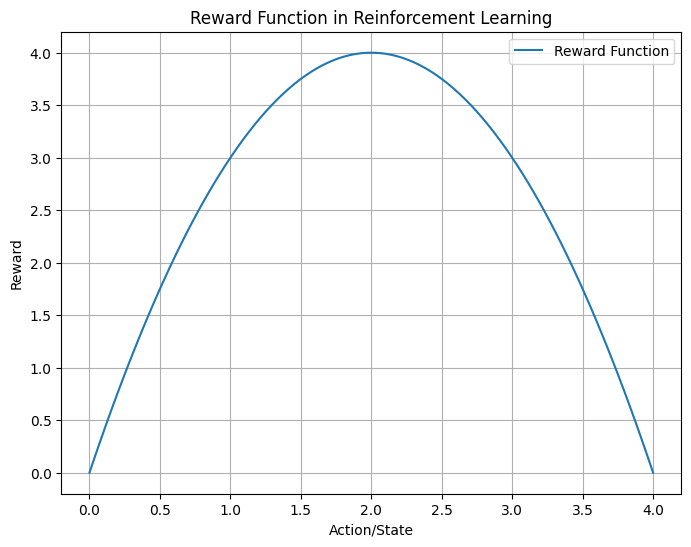

=== Research Summary ===
### แนวคิดหลักของ Reinforcement Learning

Reinforcement Learning (RL) เป็นแนวคิดในปัญญาประดิษฐ์ที่เกี่ยวข้องกับการเรียนรู้ผ่านการทดลองและการตอบสนองจากสิ่งแวดล้อม โดยมีเป้าหมายเพื่อเพิ่มผลตอบแทนสะสมสูงสุดในระยะยาว ระบบ RL ประกอบด้วยองค์ประกอบหลักคือ ตัวแทน (Agent) ที่ทำการกระทำ (Action) ในสภาวะ (State) และได้รับรางวัล (Reward) จากสิ่งแวดล้อม (Environment) การเรียนรู้เกิดขึ้นเมื่อ Agent ปรับปรุงนโยบาย (Policy) เพื่อเพิ่มรางวัลสะสม [Wikipedia: Reinforcement Learning](https://th.wikipedia.org/wiki/%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%98%E0%B8%B2%E0%B8%99%E0%B8%A8%E0%B8%B1%E0%B8%9E%E0%B8%97%E0%B9%8C%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%9B%E0%B8%A3%E0%B8%B0%E0%B8%94%E0%B8%B4%E0%B8%A9%E0%B8%90%E0%B9%8C).

### Reward Function

Reward Function เป็นส่วนสำคัญใน RL ที่กำหนดว่าการกระทำใดจะได้รับรางวัลมากน้อยเพียงใด ซึ่งส่งผลต่อการปรับปรุงนโยบายของ Agent โดยรางวัลจะทำหน้าที่เป็นตัวเสริมแรง (Reinforcer) ที่ช่วยเพิ่มความถี่ของพฤติกรรมที่ต้องการ [Wikipedia: Reward Fu

In [15]:


q = questions[0]
res = multi_agent_system(q)
show_research(res)
show_code(res)
show_mixture(res)
